In [1]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 📊 Étape 4 : Visualisation Multidimensionnelle (Squelette Étudiant)

L'objectif est de concevoir des représentations visuelles premium pour identifier des tendances et insights clés.

### Préparation de l'environnement

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
# from src import data_clean as dc
# from src import utils_viz as uv

# Activation du style premium personnalisé (light ou dark)
# uv.set_custom_style(theme='light')
%matplotlib inline
print("Librairies de visualisation prêtes !")

Librairies de visualisation prêtes !


### Chargement du dataset enrichi

In [3]:
df = pd.read_csv('../data/processed/cleaned_data_sample.csv')

df.head()

,Company,TypeName,Inches,Ram,OpSys,Price,Res_Width,Res_Height,Is_IPS,Cpu_Gamme,...,has_ssd,has_hdd,has_flash,has_hybrid,total_memory_gb,gpu_brand,has_intel_gpu,has_nvidia_gpu,has_amd_gpu,weight_kg
0,Apple,Ultrabook,13.3,8,macOS,71378.6832,2560,1600,1,Intel Core i5,...,1,0,0,0,128.0,Intel,1,0,0,1.37
1,Apple,Ultrabook,13.3,8,macOS,47895.5232,1440,900,0,Intel Core i5,...,0,0,1,0,128.0,Intel,1,0,0,1.34
2,HP,Notebook,15.6,8,No OS,30636.0000,1920,1080,0,Intel Core i5,...,1,0,0,0,256.0,Intel,1,0,0,1.86
3,Apple,Ultrabook,15.4,16,macOS,135195.3360,2880,1800,1,Intel Core i7,...,1,0,0,0,512.0,AMD,0,0,1,1.83
4,Apple,Ultrabook,13.3,8,macOS,96095.8080,2560,1600,1,Intel Core i5,...,1,0,0,0,256.0,Intel,1,0,0,1.37


### Tracés et analyses graphiques

#### Distribution des prix

['Company', 'TypeName', 'Inches', 'Ram', 'OpSys', 'Price', 'Res_Width', 'Res_Height', 'Is_IPS', 'Cpu_Gamme', 'Cpu_Frequence_GHz', 'has_ssd', 'has_hdd', 'has_flash', 'has_hybrid', 'total_memory_gb', 'gpu_brand', 'has_intel_gpu', 'has_nvidia_gpu', 'has_amd_gpu', 'weight_kg']


,Company,TypeName,Inches,Ram,OpSys,Price,Res_Width,Res_Height,Is_IPS,Cpu_Gamme,...,has_ssd,has_hdd,has_flash,has_hybrid,total_memory_gb,gpu_brand,has_intel_gpu,has_nvidia_gpu,has_amd_gpu,weight_kg
0,Apple,Ultrabook,13.3,8,macOS,71378.6832,2560,1600,1,Intel Core i5,...,1,0,0,0,128.0,Intel,1,0,0,1.37
1,Apple,Ultrabook,13.3,8,macOS,47895.5232,1440,900,0,Intel Core i5,...,0,0,1,0,128.0,Intel,1,0,0,1.34
2,HP,Notebook,15.6,8,No OS,30636.0000,1920,1080,0,Intel Core i5,...,1,0,0,0,256.0,Intel,1,0,0,1.86
3,Apple,Ultrabook,15.4,16,macOS,135195.3360,2880,1800,1,Intel Core i7,...,1,0,0,0,512.0,AMD,0,0,1,1.83
4,Apple,Ultrabook,13.3,8,macOS,96095.8080,2560,1600,1,Intel Core i5,...,1,0,0,0,256.0,Intel,1,0,0,1.37


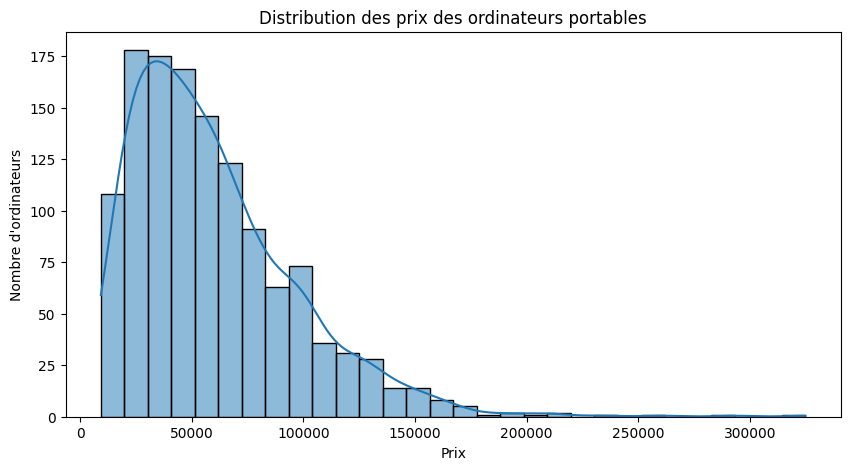

In [4]:
# vérification des colonnes
print(df.columns.tolist())
display(df.head())

plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="Price", bins=30, kde=True)

plt.title("Distribution des prix des ordinateurs portables")
plt.xlabel("Prix")
plt.ylabel("Nombre d'ordinateurs")

plt.show()

**Analyse de la distribution des prix**

Ce graphique permet d’analyser la distribution de la variable `Price`, qui correspond au prix des ordinateurs portables présents dans le jeu de données.

* Les prix des ordinateurs portables ne sont pas répartis de manière uniforme. La majorité des ordinateurs se situent dans une tranche de prix basse à moyenne, tandis que quelques modèles présentent des prix beaucoup plus élevés.


**Conclusion**

* La distribution des prix est concentrée sur les segments bas et moyens.
* Quelques modèles haut de gamme tirent la distribution vers la droite.
* Ces valeurs extrêmes peuvent influencer la modélisation de `Price`.

#### Répartition des marques

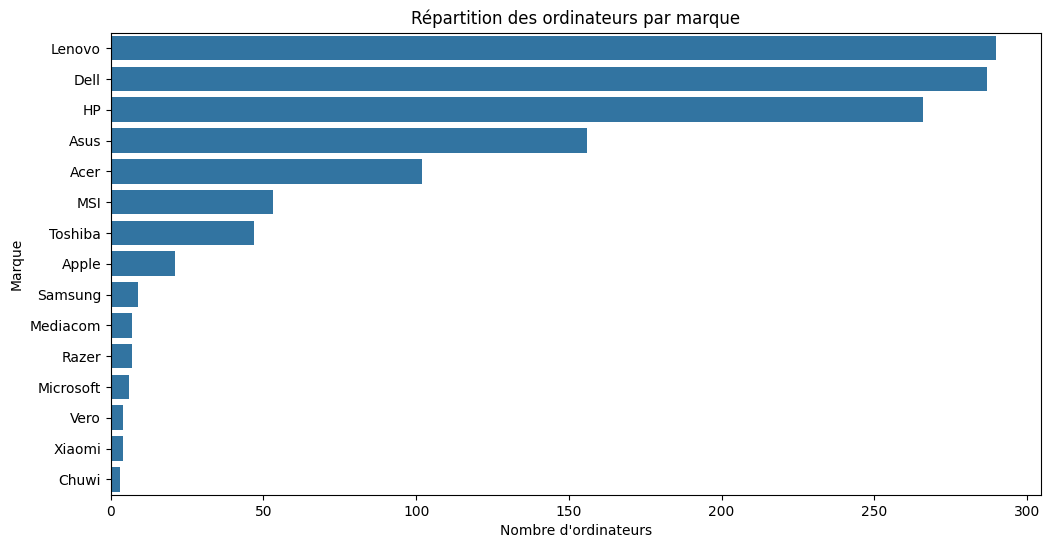

In [5]:
plt.figure(figsize=(12, 6))

company_counts = df["Company"].value_counts().head(15)

sns.barplot(
    x=company_counts.values,
    y=company_counts.index
)

plt.title("Répartition des ordinateurs par marque")
plt.xlabel("Nombre d'ordinateurs")
plt.ylabel("Marque")

plt.show()

**Analyse de la répartition des marques**

Ce graphique permet d’étudier la répartition des ordinateurs portables selon leur marque, représentée par la variable `Company`.
Le barplot a été choisi car `Company` est une variable catégorielle. 


* Lenovo, Dell et HP dominent le jeu de données.
* Plusieurs marques sont présentes avec un faible volume d’observations.
* Le dataset est déséquilibré sur la variable `Company`.

**Conclusion**

* Quelques marques concentrent la majorité des ordinateurs.
* Les marques peu représentées devront être interprétées avec prudence.
* Cette variable peut influencer les analyses et les modèles.

#### Répartition des types d'ordinateurs


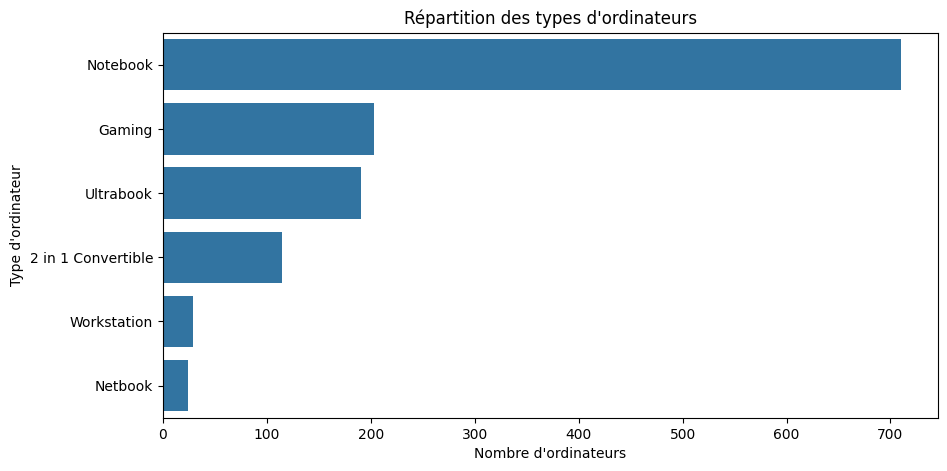

In [6]:
type_counts = df["TypeName"].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=type_counts.values,
    y=type_counts.index
)

plt.title("Répartition des types d'ordinateurs")
plt.xlabel("Nombre d'ordinateurs")
plt.ylabel("Type d'ordinateur")

plt.show()

**Analyse de la répartition des types d'ordinateurs**

Ce graphique permet d’analyser la répartition des ordinateurs portables selon leur type, représenté par la variable `TypeName`.
* Les notebooks sont les ordinateurs le plus représentés dans le dataset. 



**Conclusion**

* Forte domination des notebooks dans le jeu de données.

#### Prix moyen par marque


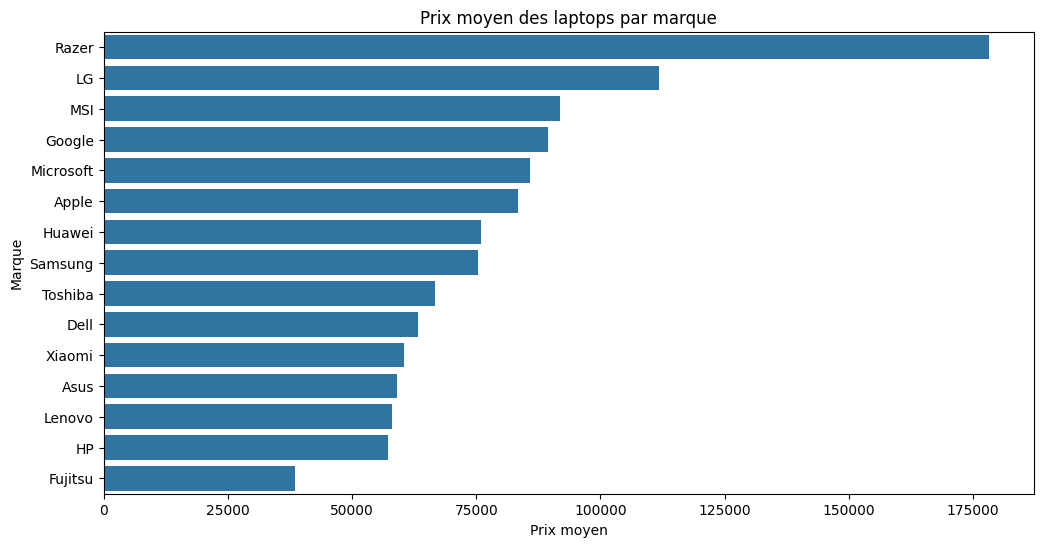

In [7]:
price_by_company = (
    df.groupby("Company")["Price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=price_by_company.values, y=price_by_company.index)

plt.title("Prix moyen des laptops par marque")
plt.xlabel("Prix moyen")
plt.ylabel("Marque")

plt.show()

**Analyse du prix moyen des laptops par marque**

Le graphique sert à identifier le prix moyen des ordinateurs en fonction des marques.

* Razer représente la marque la plus chère, suivie de LG et de MSI.

**Conclusion**

* Différences importantes de prix moyen selon les marques. 
* La marque peut être une variable explicative intéressante pour comprendre le prix des ordinateurs portables. 

#### Relation poids / prix

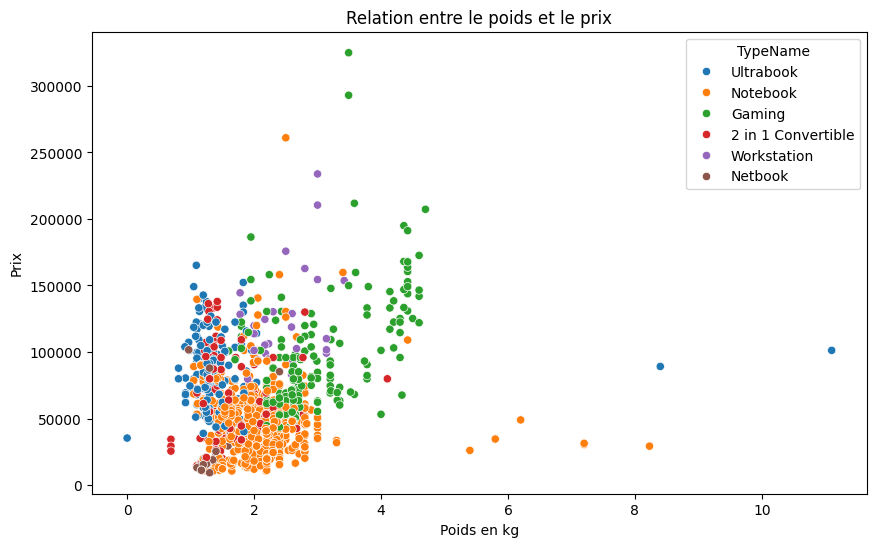

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="weight_kg", y="Price", hue="TypeName")
plt.title("Relation entre le poids et le prix")
plt.xlabel("Poids en kg")
plt.ylabel("Prix")
plt.show()

**Analyse de la relation entre le poids et le prix**

Ce graphique permet d'analyser la relation entre le poids, le type et le prix d'un ordinateur.

* La majorité des ordinateurs portables se situe entre 1 kg et 3 kg.
* Les ordinateurs de type gaming sont souvent plus lourds et ont tendance à être plus chers.
* La relation entre le poids et le prix ne semblent pas parfaitement linéaire.

**Conclusion**

* Le poids seul n’explique pas entièrement le prix d’un ordinateur portable. 
* Les ordinateurs gaming ou professionnels sont souvent plus lourds et plus chers.
* Les ultrabooks sont généralement plus légers mais peuvent aussi atteindre des prix élevés. 

#### Relation stockage / prix

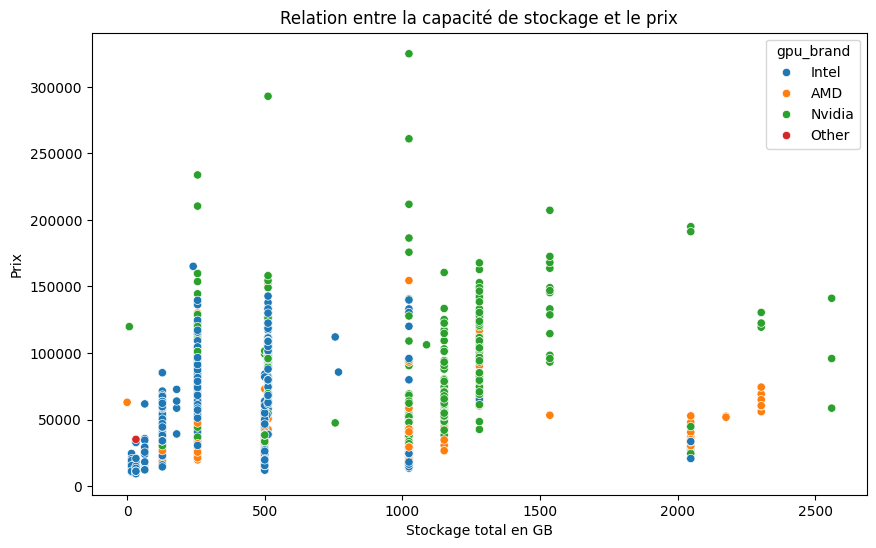

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="total_memory_gb", y="Price", hue="gpu_brand")

plt.title("Relation entre la capacité de stockage et le prix")
plt.xlabel("Stockage total en GB")
plt.ylabel("Prix")

plt.show()

**Analyse**

Ce graphique permet de comprendre la relation entre la capacité de stockage et le prix de l'ordinateur.

* Les ordinateurs portables sont principalement regroupés autour de certaines capacités de stockage.
* Les prix sont assez dispersés pour une même capacité de stockage.
* Les ordinateurs équipés d'un GPU Nvidia sont souvent associés à des prix plus élevés.

**Conclusion**

* La capacité totale de stockage n’explique pas à elle seule le prix d’un ordinateur portable. 
* Les modèles avec de grandes capacités peuvent parfois être plus chers, mais les prix restent très variables pour une même quantité de stockage. 

#### Matrice de corrélation

Price                float64
Ram                    int64
Inches               float64
Res_Width              int64
Res_Height             int64
Cpu_Frequence_GHz    float64
total_memory_gb      float64
weight_kg            float64
has_ssd                int64
has_hdd                int64
has_flash              int64
has_hybrid             int64
has_intel_gpu          int64
has_nvidia_gpu         int64
has_amd_gpu            int64
dtype: object

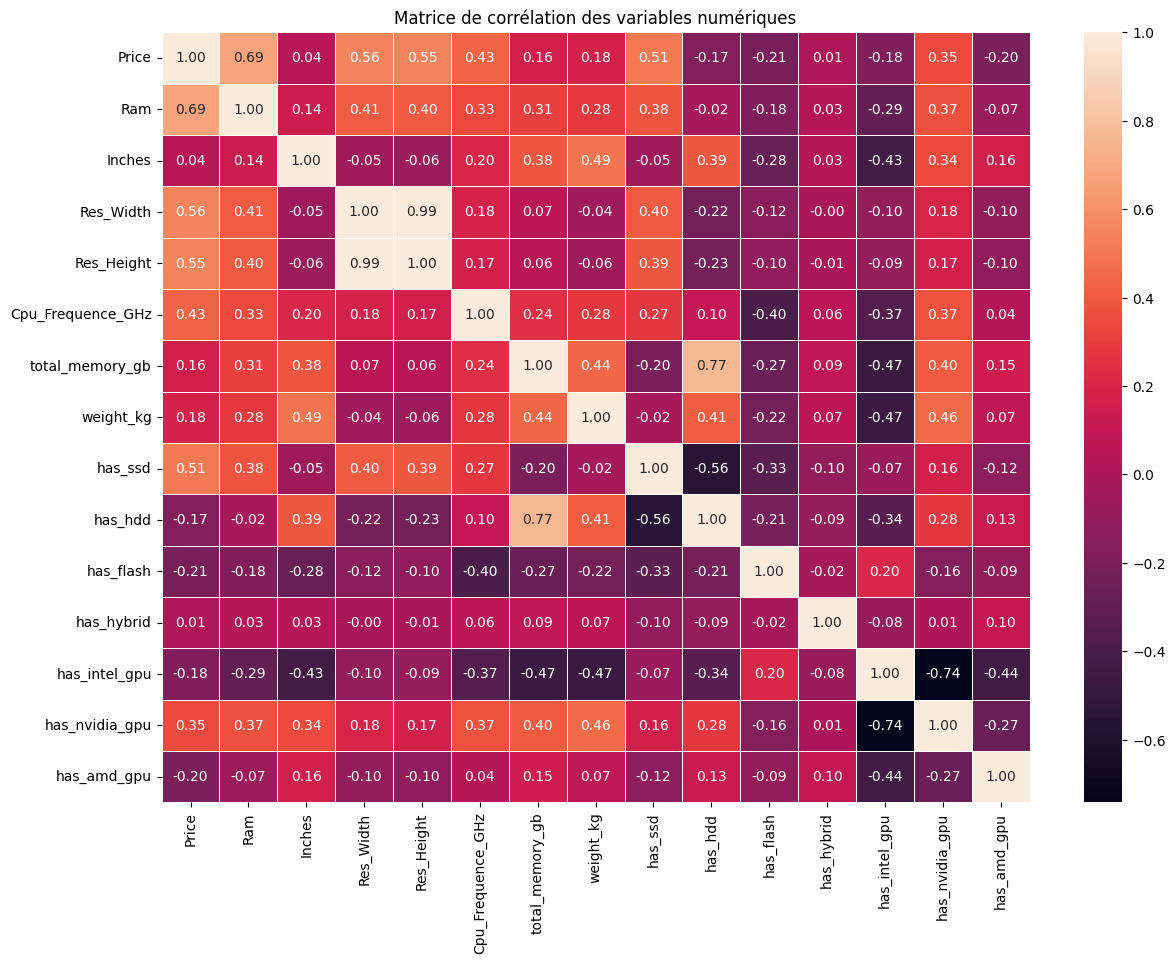

In [10]:
selected_numeric_columns = [
    "Price",
    "Ram",
    "Inches",
    "Res_Width",
    "Res_Height",
    "Cpu_Frequence_GHz",
    "total_memory_gb",
    "weight_kg",
    "has_ssd",
    "has_hdd",
    "has_flash",
    "has_hybrid",
    "has_intel_gpu",
    "has_nvidia_gpu",
    "has_amd_gpu"
]

numeric_df = df[selected_numeric_columns].copy()

# Conversion sécurisée en numérique
# for col in selected_numeric_columns:
#     numeric_df[col] = pd.to_numeric(numeric_df[col], errors="coerce")

# print("Valeurs manquantes après conversion numérique :")
# display(numeric_df.isnull().sum())

# Vérification rapide des types
display(numeric_df.dtypes)

# Matrice de corrélation
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matrice de corrélation des variables numériques")
plt.show()

**Analyse**

* Le graphique met en évidence la relation entre les variables étudiées et `Price`.
* Le prix est corrélé positivement avec la ram (0.69).
* Le prix est corrélé positivement avec la largeur et la hauteur de résolution de l'écran (0.56 et 0.55).
* La présence d'un SSD est également corrélée positivement avec le prix (0.51).
* La fréquence du processeur présente une corrélation positive avec le prix (0.43).
* La présence d'une carte graphique Nvidia est aussi positivement corrélée au prix (0.35).
* La résolution de l'écran montre une très forte corrélation positive au prix (0.99).

**Conclusion**

* Le prix semble surtout lié à des caractéristiques techniques comme la résolution de l’écran, la présence d’un SSD, la fréquence du processeur et la présence d’une carte graphique Nvidia. 
* En revanche, certaines variables comme la taille de l’écran semblent avoir peu d’influence directe sur le prix.